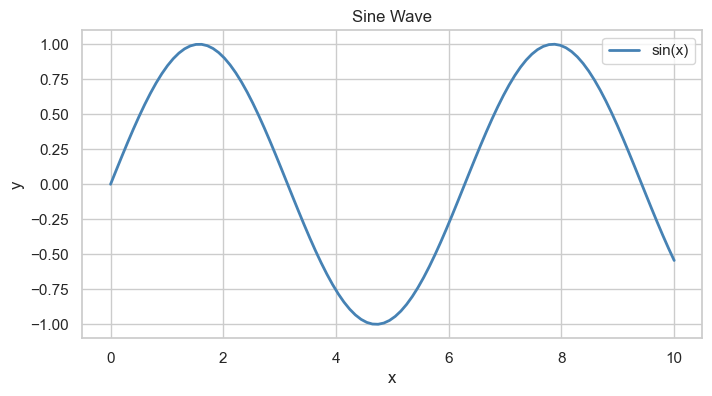

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Line plot
x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, color='steelblue', linewidth=2, label='sin(x)')
ax.set_title('Sine Wave')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.savefig('line_plot.png')
plt.show()



(891, 10)


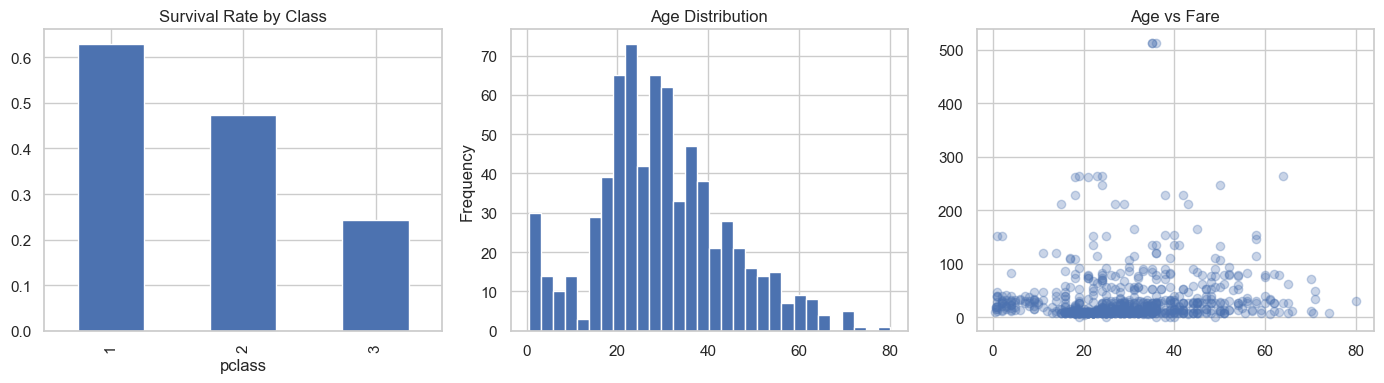

In [55]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv')
df = df.drop(columns=['adult_male', 'embarked', 'class', 'alive', 'alone'])

print(df.shape)
# Bar chart — survival by class
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Bar chart
df.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('Survival Rate by Class')

# 2. Histogram
df['age'].dropna().plot(kind='hist', bins=30, ax=axes[1])
axes[1].set_title('Age Distribution')

# 3. Scatter plot
axes[2].scatter(df['age'], df['fare'], alpha=0.3)
axes[2].set_title('Age vs Fare')

plt.tight_layout()
plt.show()

In [56]:
df.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,who,deck,embark_town
0,0,3,male,22.0,1,0,7.2500,man,NaN,Southampton
1,1,1,female,38.0,1,0,71.2833,woman,C,Cherbourg
2,1,3,female,26.0,0,0,7.9250,woman,NaN,Southampton
3,1,1,female,35.0,1,0,53.1000,woman,C,Southampton
4,0,3,male,35.0,0,0,8.0500,man,NaN,Southampton


In [57]:
test = df[-5:]
print(test)

     survived  pclass     sex   age  sibsp  parch   fare    who deck  \
886         0       2    male  27.0      0      0  13.00    man  NaN   
887         1       1  female  19.0      0      0  30.00  woman    B   
888         0       3  female   NaN      1      2  23.45  woman  NaN   
889         1       1    male  26.0      0      0  30.00    man    C   
890         0       3    male  32.0      0      0   7.75    man  NaN   

     embark_town  
886  Southampton  
887  Southampton  
888  Southampton  
889    Cherbourg  
890   Queenstown  


In [58]:
df = df[:-5]
print(df.shape)

(886, 10)


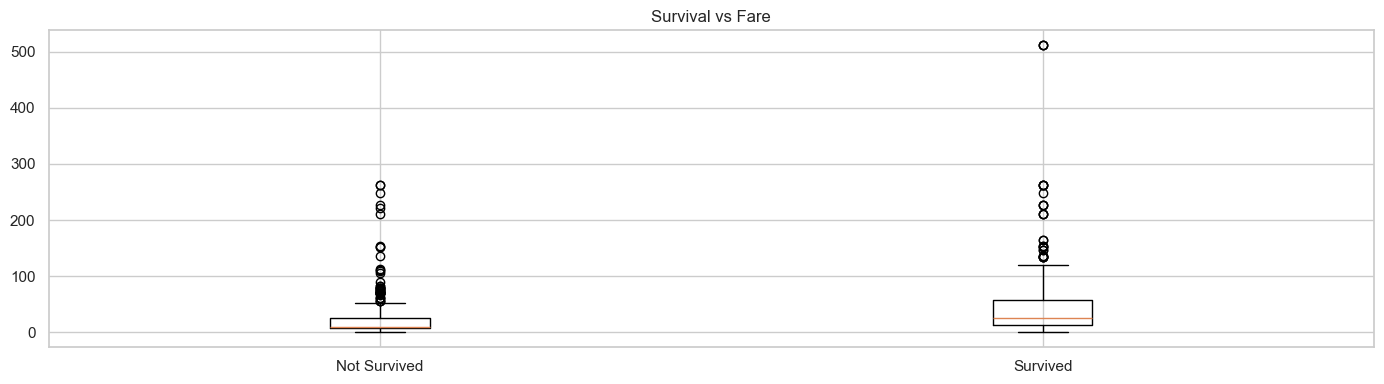

In [59]:
fig, axes = plt.subplots(1, 1, figsize=(14, 4))

# 1. Bar chart
# df.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[0])
# axes[0].set_title('Survival Rate by Class')

# # 2. Histogram
# df['age'].dropna().plot(kind='hist', bins=30, ax=axes[1])
# axes[1].set_title('Age Distribution')

# 3. Scatter plot
axes.boxplot([df[df['survived']==0]['fare'], df[df['survived']==1]['fare']], labels=['Not Survived', 'Survived'])
axes.set_title('Survival vs Fare')

plt.tight_layout()
plt.show()

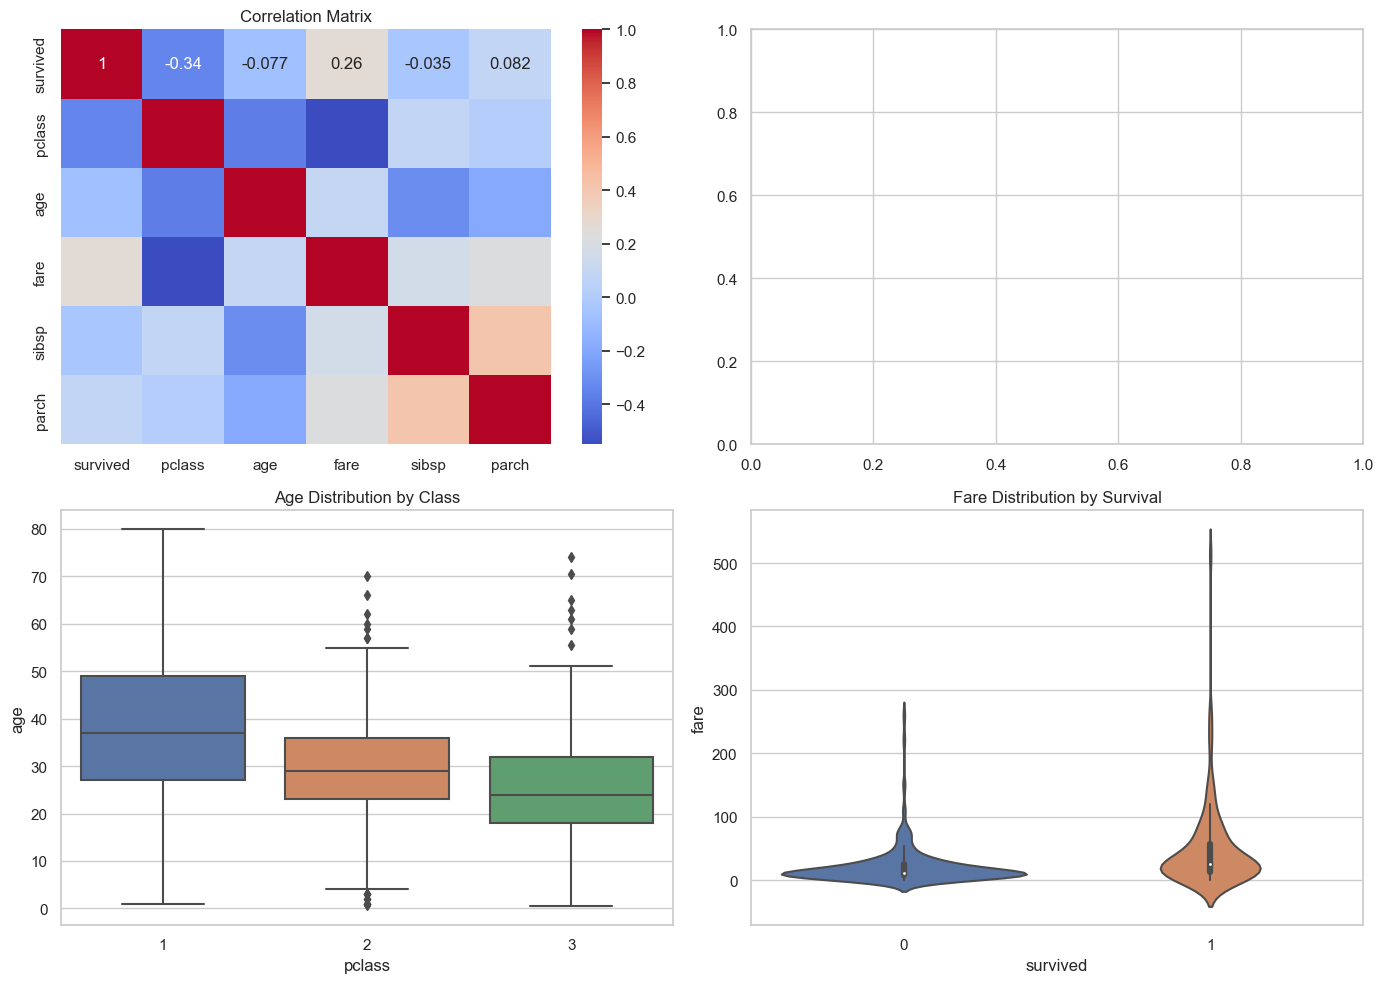

In [60]:
import seaborn as sns
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv')
df = df.drop(columns=['adult_male'])
sns.set_theme(style='whitegrid')

# Heatmap — correlations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Correlation heatmap
corr = df[['survived','pclass','age','fare','sibsp','parch']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[0][0])
axes[0][0].set_title('Correlation Matrix')

# Count plot (categorical)
# sns.countplot(data=df, x='pclass', hue='survived', ax=axes[0][1])
# axes[0][1].set_title('Survival Count by Class')

# Box plot
sns.boxplot(data=df, x='pclass', y='age', ax=axes[1][0])
axes[1][0].set_title('Age Distribution by Class')

# Violin plot
sns.violinplot(data=df, x='survived', y='fare', ax=axes[1][1])
axes[1][1].set_title('Fare Distribution by Survival')

plt.tight_layout()
plt.show()

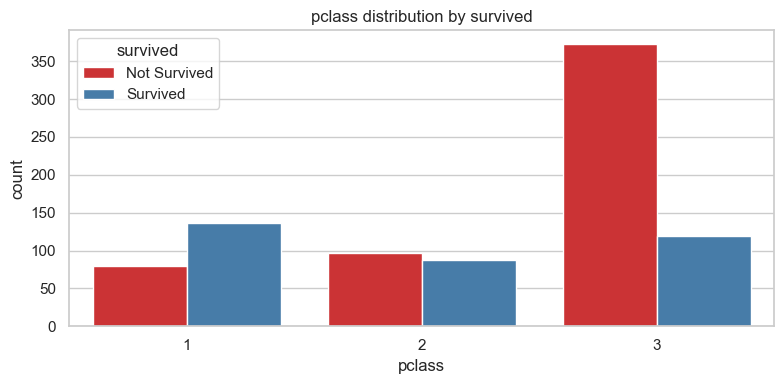

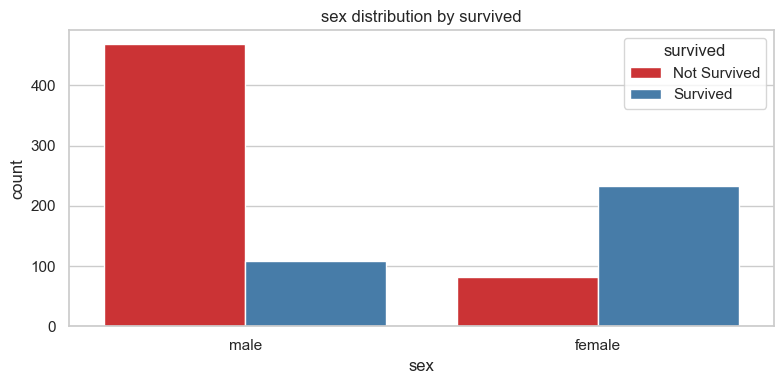

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(


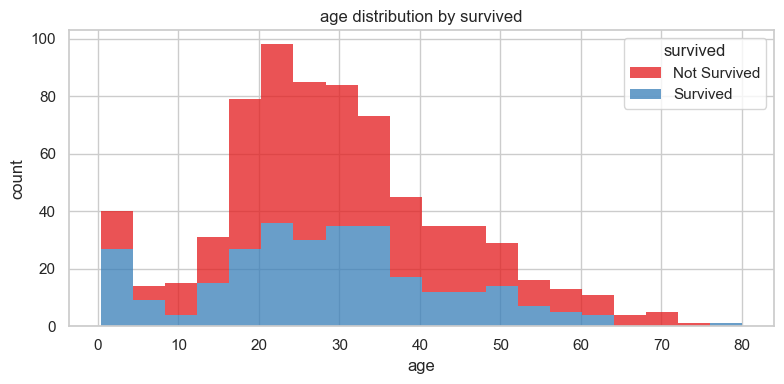

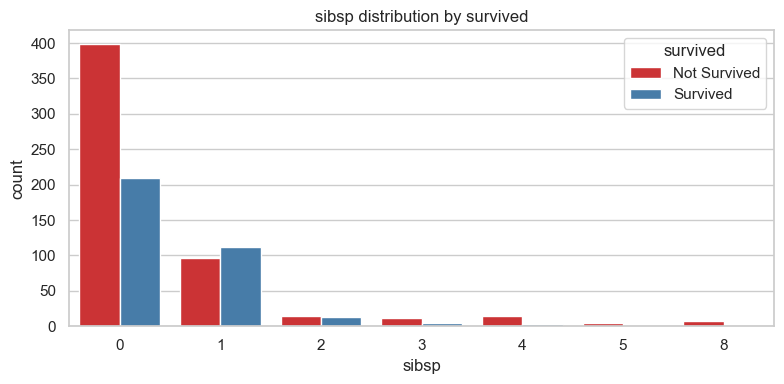

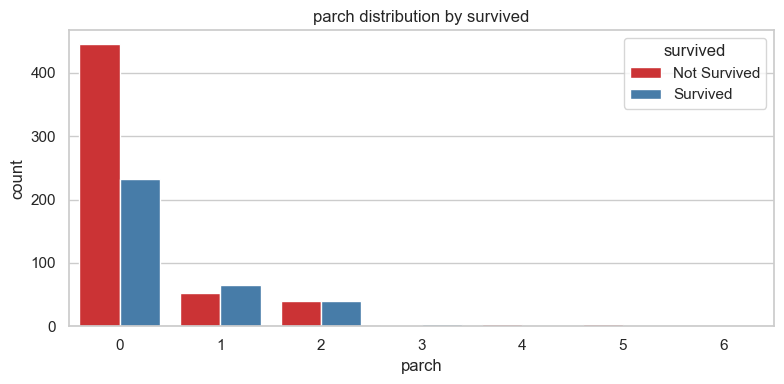

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(


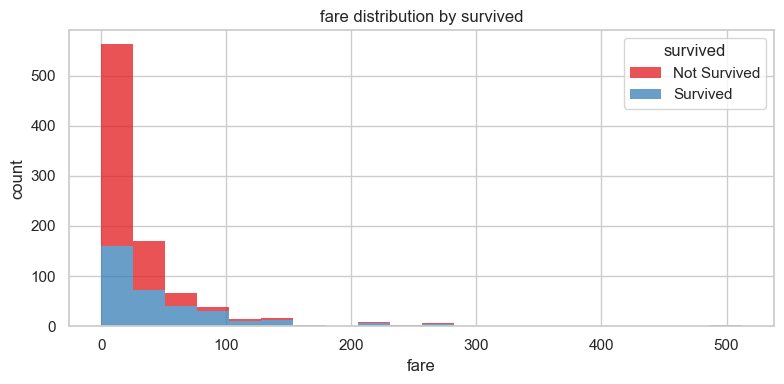

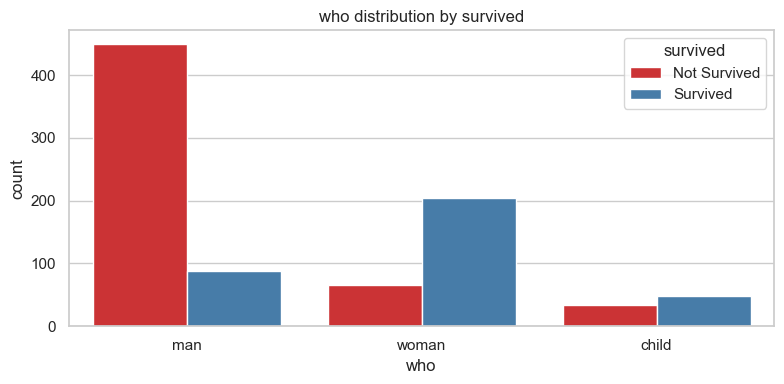

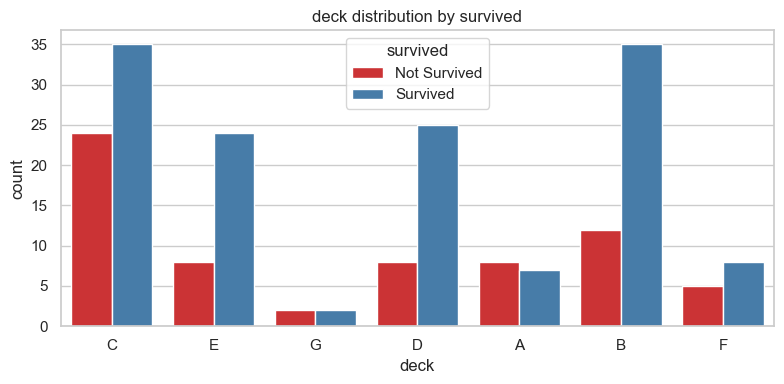

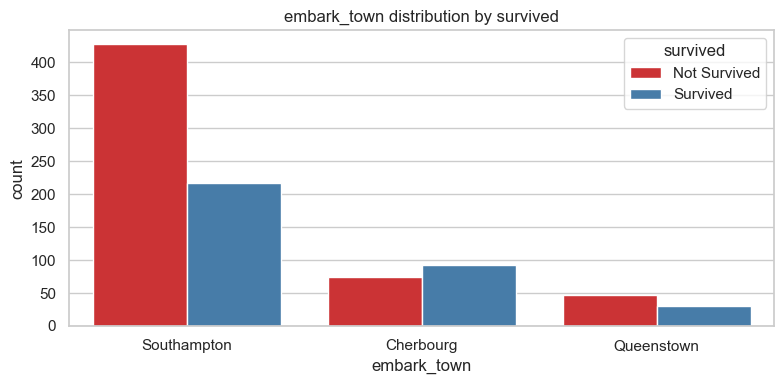

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reload the dataset and keep the same columns used earlier.
df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv')
df = df.drop(columns=['adult_male', 'embarked', 'class', 'alive', 'alone'])

df['survived'] = df['survived'].map({0: 'Not Survived', 1: 'Survived'}).astype('category')

sns.set_theme(style='whitegrid')
features = [col for col in df.columns if col != 'survived']

for col in features:
    plt.figure(figsize=(8, 4))
    if df[col].dtype == 'object' or df[col].nunique() < 10:
        sns.countplot(data=df, x=col, hue='survived', hue_order=['Not Survived', 'Survived'], palette='Set1')
        plt.title(f'{col} distribution by survived')
        plt.xlabel(col) 
        plt.ylabel('count')
    else:
        sns.histplot(data=df, x=col, hue='survived', hue_order=['Not Survived', 'Survived'], multiple='stack', bins=20, edgecolor='none', palette='Set1')
        plt.title(f'{col} distribution by survived')
        plt.xlabel(col)
        plt.ylabel('count')
    plt.tight_layout()
    plt.show()

In [74]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv')

# Calculate survival percentage for age 35
age_35 = df[df['age'] == 35]
survived_35 = age_35['survived'].sum()
total_35 = len(age_35)
perc_35 = (survived_35 / total_35 * 100) if total_35 > 0 else 0

# Calculate survival percentage for age 50
age_50 = df[df['age'] == 50]
survived_50 = age_50['survived'].sum()
total_50 = len(age_50)
perc_50 = (survived_50 / total_50 * 100) if total_50 > 0 else 0

print(f"Age 35: {perc_35:.2f}% survived ({survived_35}/{total_35})")
print(f"Age 50: {perc_50:.2f}% survived ({survived_50}/{total_50})")


Age 35: 61.11% survived (11/18)
Age 50: 50.00% survived (5/10)


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(


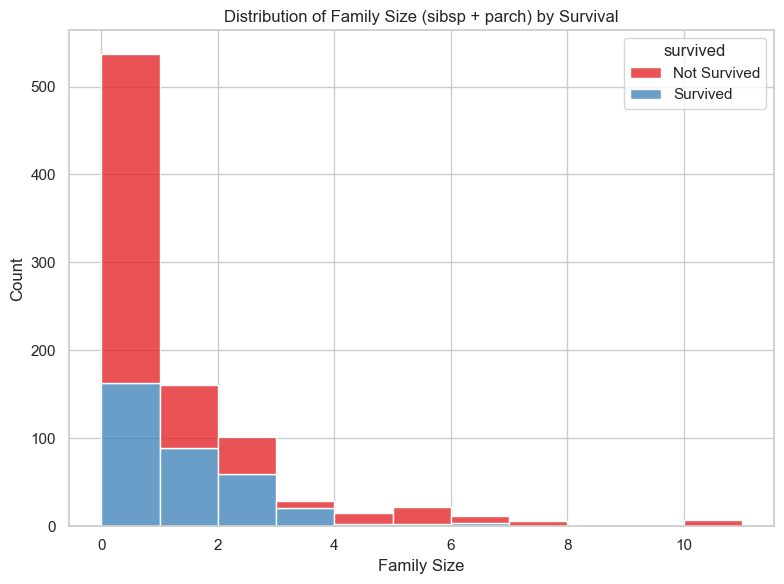

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv')
df['family_size'] = df['sibsp'] + df['parch']

df['survived'] = df['survived'].map({0: 'Not Survived', 1: 'Survived'}).astype('category')

plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='family_size', hue='survived', hue_order=['Not Survived', 'Survived'], multiple='stack', bins=range(0, 12), palette='Set1')
plt.title('Distribution of Family Size (sibsp + parch) by Survival')
plt.xlabel('Family Size')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(


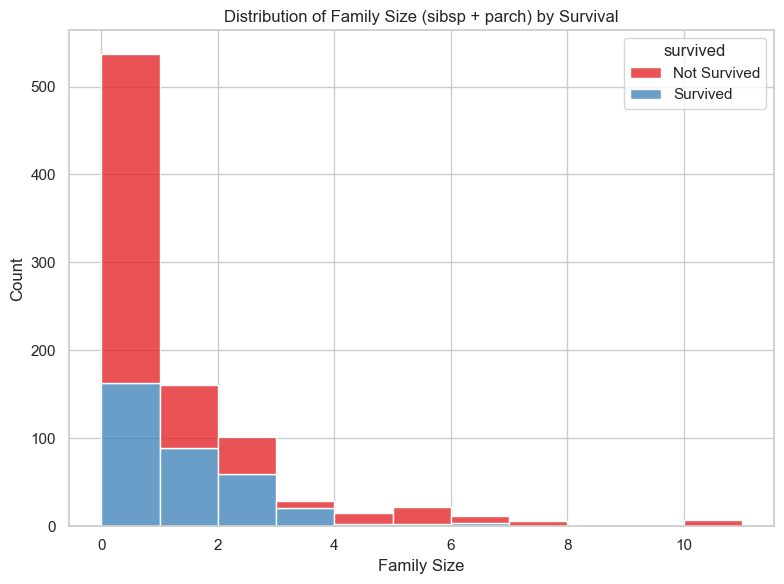

In [76]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv')
df['family_size'] = df['sibsp'] + df['parch']

df['survived'] = df['survived'].map({0: 'Not Survived', 1: 'Survived'}).astype('category')

plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='family_size', hue='survived', hue_order=['Not Survived', 'Survived'], multiple='stack', bins=range(0, 12), palette='Set1')
plt.title('Distribution of Family Size (sibsp + parch) by Survival')
plt.xlabel('Family Size')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


HOMEWORK: in a new ipynb file, for titanic data, run a decision tree model on training set (not test set) and provide numbers for training set. Do a random forest model too. Can ask copilot to help with code, and analyse which one (tree or forest) works best. Other models that I can try: SVM, Logistic/linear regression, naive bayes, neural network model. 